<a href="https://colab.research.google.com/github/adapasriram/US_HONEY_PRODUCTION/blob/main/E-commerce%20Customer%20Behavior%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt

In [4]:
df = pd.read_csv('Ecommerce.csv')


In [5]:
df.head()

,customer_id,session_id,visit_date,device_type,user_type,marketing_channel,product_id,product_category,unit_price,quantity,...,review_text,review_helpful_votes,payment_method,visit_day,visit_month,visit_weekday,visit_season,session_duration_bucket,revenue_normalized,location
0,1803,0,28-11-2024,2,1,2,894,6,651.57,1,...,1,0,1,28,11,3,0,Long,0.000000,209
1,7964,1,25-09-2024,2,0,4,844,2,945.27,4,...,1,0,2,25,9,2,0,Long,0.000000,213
2,6890,2,31-05-2024,1,1,0,865,0,400.44,4,...,1,0,2,31,5,4,1,Short,0.000000,10
3,4949,3,30-01-2024,1,0,2,851,3,1268.54,2,...,10,4,1,30,1,1,3,Very Long,0.305504,46
4,4896,4,25-02-2024,1,1,5,794,3,880.81,3,...,1,0,1,25,2,6,3,Very Short,0.000000,118


In [6]:
df.shape

(25000, 29)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              25000 non-null  int64  
 1   session_id               25000 non-null  int64  
 2   visit_date               25000 non-null  object 
 3   device_type              25000 non-null  int64  
 4   user_type                25000 non-null  int64  
 5   marketing_channel        25000 non-null  int64  
 6   product_id               25000 non-null  int64  
 7   product_category         25000 non-null  int64  
 8   unit_price               25000 non-null  float64
 9   quantity                 25000 non-null  int64  
 10  discount_percent         25000 non-null  int64  
 11  discount_amount          25000 non-null  float64
 12  revenue                  25000 non-null  float64
 13  pages_viewed             25000 non-null  int64  
 14  time_on_site_sec      

In [8]:
df.isnull().sum()

,0
customer_id,0
session_id,0
visit_date,0
device_type,0
user_type,0
marketing_channel,0
product_id,0
product_category,0
unit_price,0
quantity,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,customer_id,session_id,device_type,user_type,marketing_channel,product_id,product_category,unit_price,quantity,discount_percent,...,rating,review_text,review_helpful_votes,payment_method,visit_day,visit_month,visit_weekday,visit_season,revenue_normalized,location
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,...,25000.00000,25000.00000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000
mean,5479.930600,12499.500000,0.705040,0.551280,2.514040,449.107000,3.495240,782.319010,2.489040,8.99880,...,3.94800,1.67488,5.52080,2.483160,15.714520,6.510520,2.980800,1.504400,0.051290,111.70692
std,2593.544596,7217.022701,0.639543,0.497373,1.704934,259.513787,2.285053,476.612168,1.114563,9.26364,...,0.54047,1.98673,12.33629,1.709501,8.796338,3.457925,1.992554,1.117475,0.129591,65.07079
min,1000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.050000,1.000000,0.00000,...,1.00000,0.00000,0.00000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,3234.000000,6249.750000,0.000000,0.000000,1.000000,225.000000,2.000000,395.222500,1.000000,0.00000,...,4.00000,1.00000,0.00000,1.000000,8.000000,3.000000,1.000000,1.000000,0.000000,55.00000
50%,5482.000000,12499.500000,1.000000,1.000000,2.000000,448.000000,4.000000,691.725000,2.000000,10.00000,...,4.00000,1.00000,0.00000,2.000000,16.000000,7.000000,3.000000,2.000000,0.000000,111.00000
75%,7715.000000,18749.250000,1.000000,1.000000,4.000000,675.000000,5.000000,1096.842500,3.000000,15.00000,...,4.00000,1.00000,0.00000,4.000000,23.000000,10.000000,5.000000,3.000000,0.000000,169.00000
max,9998.000000,24999.000000,2.000000,1.000000,5.000000,898.000000,7.000000,1999.830000,4.000000,30.00000,...,5.00000,10.00000,49.00000,5.000000,31.000000,12.000000,6.000000,3.000000,1.000000,224.00000


In [11]:
df['device_type'].value_counts()

,count
device_type,
1,12600
0,9887
2,2513


<Axes: xlabel='device_type'>

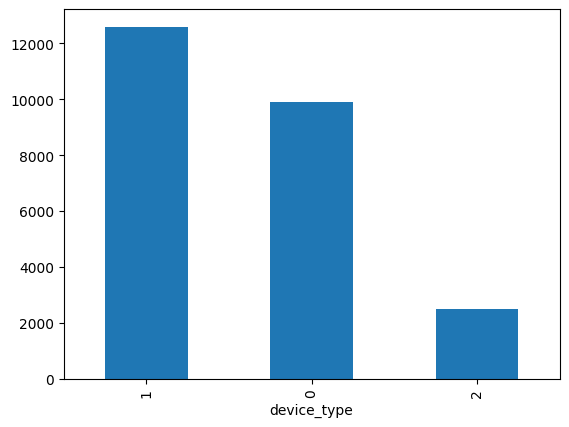

In [12]:
df['device_type'].value_counts().plot(kind='bar')

In [13]:
df['marketing_channel'].value_counts()

,count
marketing_channel,
2,4281
5,4263
1,4190
3,4116
4,4109
0,4041


<Axes: xlabel='marketing_channel'>

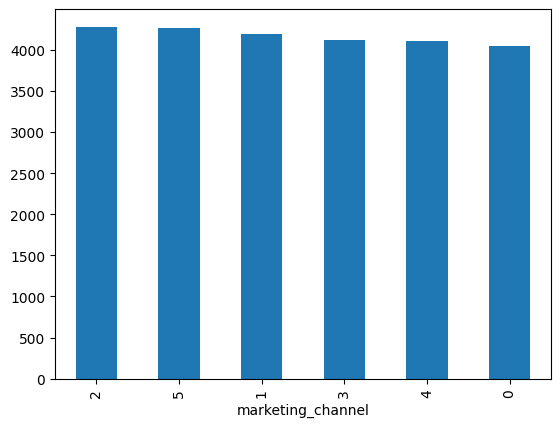

In [14]:
df['marketing_channel'].value_counts().plot(kind='bar')

In [15]:
purchase_rate = df['purchased'].value_counts(normalize=True)*100
purchase_rate

,proportion
purchased,
0,77.536
1,22.464


In [16]:
df['cart_abandoned'].value_counts()

,count
cart_abandoned,
0,14499
1,10501


In [17]:
df['cart_abandoned'].value_counts(normalize=True)*100

,proportion
cart_abandoned,
0,57.996
1,42.004


In [19]:
df.groupby('product_category')['revenue'].sum().sort_values(ascending =False)

,revenue
product_category,
2,2037576.79
6,1930885.22
5,1729167.16
3,1293649.90
7,1089617.52
0,880077.03
1,702788.87
4,452406.57


<Axes: xlabel='product_category'>

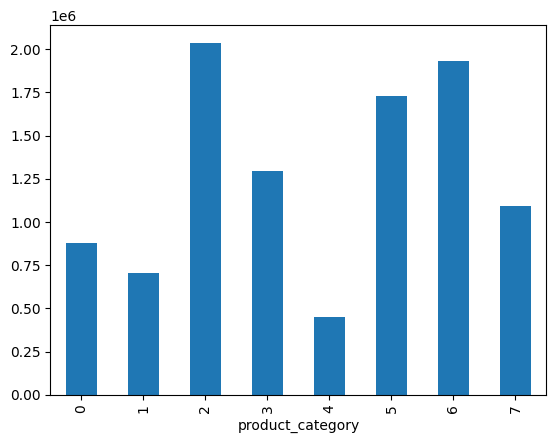

In [20]:
df.groupby('product_category')['revenue'].sum().plot(kind='bar')

In [21]:
df['payment_method'].value_counts()

,count
payment_method,
1,4281
4,4229
0,4227
3,4140
5,4072
2,4051


In [22]:
df.groupby('marketing_channel')['revenue'].sum().sort_values(ascending=False)

,revenue
marketing_channel,
5,1820823.79
2,1711962.69
3,1675463.47
0,1661328.76
1,1646768.68
4,1599821.67


<Axes: xlabel='marketing_channel'>

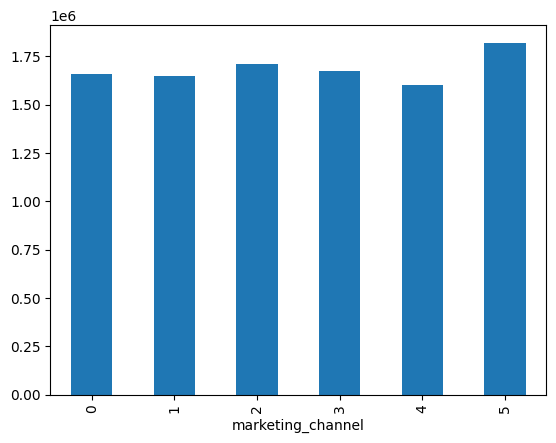

In [23]:
df.groupby('marketing_channel')['revenue'].sum().plot(kind='bar')

<Axes: xlabel='visit_weekday'>

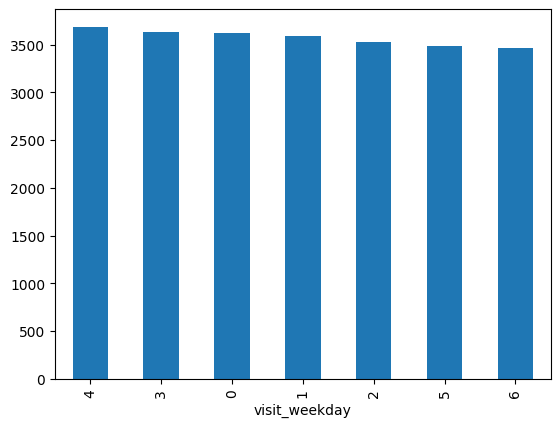

In [25]:
df['visit_weekday'].value_counts().plot(kind='bar')

<Axes: >

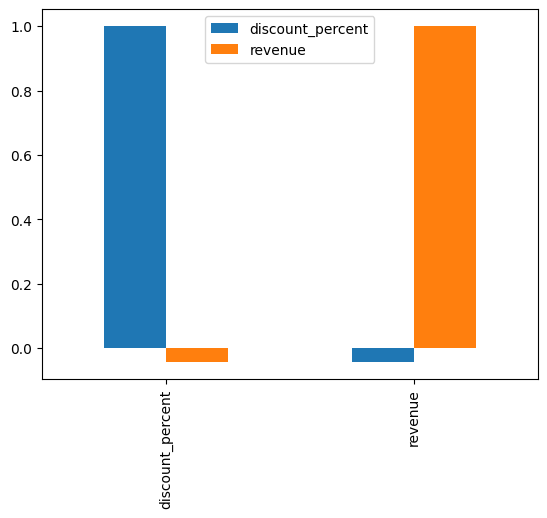

In [27]:
df[['discount_percent','revenue']].corr().plot(kind='bar')